# APE 008 - Intervalos de Confianza (Solo Tarea 1)

**Integrantes:**
* Willan Granda
* Fernando Aguirre
* Darwin Campoverde
* Byron Coronel
* Axel Jimenez
  
**Asignatura:** Teoría de la Distribución y Probabilidad  
**Fecha:** 02 de junio de 2026

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Para que los resultados sean iguales cada vez
np.random.seed(42)

### Explicación de la Tarea 1

Cuando $n \geq 30$ (muestra grande), usamos la distribución **Normal (Z)**.

**Fórmula:**
$$ IC = \bar{x} \pm Z_{\alpha/2} \left( \frac{s}{\sqrt{n}} \right) $$

In [ ]:
print("=== TAREA 1: Intervalos de Confianza para Muestras Grandes (Z) ===\n")

# 1. Datos de la muestra simulada
n_grande = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n_grande)

# 2. Estadísticos descriptivos
media_muestral = np.mean(muestra_consumo)
desv_estandar = np.std(muestra_consumo, ddof=1)
error_estandar = desv_estandar / np.sqrt(n_grande)

# 3. Cálculo del Intervalo de Confianza al 95%
nivel_confianza = 0.95
ic_inferior_z, ic_superior_z = norm.interval(
    confidence=nivel_confianza,
    loc=media_muestral,
    scale=error_estandar
)

margen_error_z = (ic_superior_z - ic_inferior_z) / 2

# Mostrar resultados
print("--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---")
print(f"Tamaño de muestra (n): {n_grande}")
print(f"Media Muestral: {media_muestral:.2f} kWh")
print(f"Margen de Error: ±{margen_error_z:.2f} kWh")
print(f"IC 95%: [{ic_inferior_z:.2f}, {ic_superior_z:.2f}] kWh")

=== TAREA 1: Intervalos de Confianza para Muestras Grandes (Z) ===

--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---
Tamaño de muestra (n): 100
Media Muestral: 345.33 kWh
Margen de Error: ±8.01 kWh
IC 95%: [337.32, 353.34] kWh


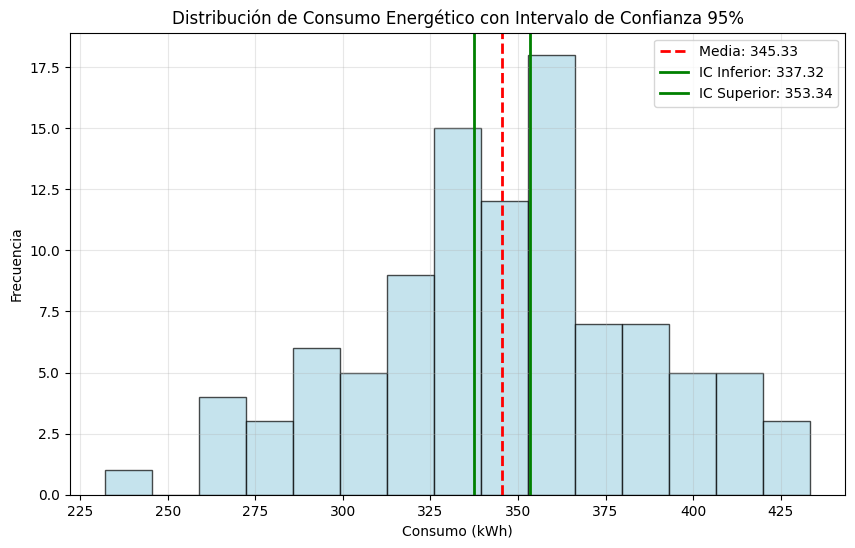

In [ ]:
# Gráfico del Intervalo de Confianza
plt.figure(figsize=(10, 6))
plt.hist(muestra_consumo, bins=15, alpha=0.7, color='lightblue', edgecolor='black')
plt.axvline(media_muestral, color='red', linestyle='--', linewidth=2, label=f'Media: {media_muestral:.2f}')
plt.axvline(ic_inferior_z, color='green', linestyle='-', linewidth=2, label=f'IC Inferior: {ic_inferior_z:.2f}')
plt.axvline(ic_superior_z, color='green', linestyle='-', linewidth=2, label=f'IC Superior: {ic_superior_z:.2f}')
plt.title('Distribución de Consumo Energético con Intervalo de Confianza 95%')
plt.xlabel('Consumo (kWh)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ==================================================
# TAREA 2 Intervalos para Muestras Pequeñas (Distribución T de Student)
# ==================================================

from scipy.stats import norm, t

# 1. Simulación de la muestra pequeña (n=12 sensores de calidad de agua)
np.random.seed(42) # Semilla para que los resultados sean reproducibles
n_pequena = 12
# Simulamos el pH del agua con media 7.2 y desviación 0.5
muestra_agua = np.random.normal(loc=7.2, scale=0.5, size=n_pequena)

# 2. Estadísticos descriptivos (Estimadores puntuales)
media_t = np.mean(muestra_agua)
# Se usa ddof=1 para la desviación estándar muestral (s)
error_estandar_t = np.std(muestra_agua, ddof=1) / np.sqrt(n_pequena)
grados_libertad = n_pequena - 1

# 3. Cálculo del Intervalo de Confianza usando T de Student (Forma Correcta)
nivel_confianza = 0.95
ic_inf_t, ic_sup_t = t.interval(confidence=nivel_confianza,
                                df=grados_libertad,
                                loc=media_t,
                                scale=error_estandar_t)

margen_error_t = (ic_sup_t - ic_inf_t) / 2

# 4. Cálculo del Intervalo usando Normal Z (Forma Errónea para comparar)
ic_inf_z, ic_sup_z = norm.interval(confidence=nivel_confianza,
                                   loc=media_t,
                                   scale=error_estandar_t)

margen_error_z = (ic_sup_z - ic_inf_z) / 2

# 5. Impresión de los resultados para evidenciar la comparación
print("--- Tarea 2: Intervalo de Confianza (Muestra Pequeña n=12) ---")
print(f"Media Muestral del pH: {media_t:.3f}")
print(f"Grados de libertad (df): {grados_libertad}")
print("-" * 50)
print(f"IC (T de Student, 95%): [{ic_inf_t:.3f}, {ic_sup_t:.3f}]")
print(f"Margen de Error (T de Student): ± {margen_error_t:.3f}")
print("-" * 50)
print("Comparativa usando erróneamente Distribución Z:")
print(f"IC (Distribución Z, 95%): [{ic_inf_z:.3f}, {ic_sup_z:.3f}]")
print(f"Margen de Error (Distribución Z): ± {margen_error_z:.3f}")

--- Tarea 2: Intervalo de Confianza (Muestra Pequeña n=12) ---
Media Muestral del pH: 7.348
Grados de libertad (df): 11
--------------------------------------------------
IC (T de Student, 95%): [7.112, 7.584]
Margen de Error (T de Student): ± 0.236
--------------------------------------------------
Comparativa usando erróneamente Distribución Z:
IC (Distribución Z, 95%): [7.137, 7.559]
Margen de Error (Distribución Z): ± 0.211


In [ ]:
# ==================================================
# TAREA 3 - HITO DEL PROYECTO (ABP)
# Estimación de la Realidad Regional
# ==================================================

# 1. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import files

# 2. Subir archivo
print("Seleccione el archivo CSV")
uploaded = files.upload()

# Obtener automáticamente el nombre del archivo
archivo = list(uploaded.keys())[0]

print(f"\nArchivo cargado: {archivo}")

# 3. Leer dataset
df = pd.read_csv(
    archivo,
    sep=';',
    encoding='latin1'
)

print("\nPrimeras filas del dataset:")
display(df.head())

# 4. Mostrar columnas disponibles
print("\nColumnas encontradas:")
print(df.columns.tolist())

# ==================================================
# VARIABLE CUANTITATIVA ESTRATÉGICA
# Temperatura media de diciembre (dic)
# ==================================================

temperatura = pd.to_numeric(
    df['dic'].astype(str).str.replace(',', '.'),
    errors='coerce'
).dropna()

# Tamaño de muestra
n = len(temperatura)

print("\n==============================")
print("ESTADÍSTICAS DE LA MUESTRA")
print("==============================")
print("Tamaño de muestra:", n)

# 5. Selección de distribución
if n >= 30:
    distribucion = "Distribución Normal (Z)"
    valor_critico = stats.norm.ppf(0.975)
else:
    distribucion = "Distribución t de Student"
    valor_critico = stats.t.ppf(0.975, df=n-1)

print("Distribución utilizada:", distribucion)

# 6. Estadísticos
media = temperatura.mean()
desv_std = temperatura.std(ddof=1)
error_estandar = desv_std / np.sqrt(n)

# 7. Intervalo de confianza al 95%
lim_inf = media - valor_critico * error_estandar
lim_sup = media + valor_critico * error_estandar

print("\n==============================")
print("RESULTADOS")
print("==============================")
print(f"Media: {media:.4f}")
print(f"Desviación estándar: {desv_std:.4f}")
print(f"Error estándar: {error_estandar:.4f}")
print(f"IC 95%: ({lim_inf:.4f}, {lim_sup:.4f})")

# ==================================================
# GRÁFICO DEL INTERVALO DE CONFIANZA
# ==================================================

plt.figure(figsize=(8,5))

plt.errorbar(
    x=1,
    y=media,
    yerr=[[media-lim_inf], [lim_sup-media]],
    fmt='o',
    capsize=8
)

plt.title('Media e Intervalo de Confianza al 95%')
plt.ylabel('Temperatura Media (°C)')
plt.xticks([1], ['Temperatura Diciembre'])
plt.grid(True)

plt.show()

In [ ]:
# ==================================================
# TAREA 4 - El Impacto del Nivel de Confianza (1 - α )
# ==================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)
n_grande = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n_grande)
media_muestral = np.mean(muestra_consumo)
error_estandar = np.std(muestra_consumo, ddof=1) / np.sqrt(n_grande)

# Tarea 4: 1. Bucle para calcular los márgenes de error
niveles_confianza = [0.80, 0.90, 0.95, 0.99]
margenes_error = []

for nivel in niveles_confianza:
    ic_inferior_z, ic_superior_z = norm.interval(confidence=nivel,
                                                 loc=media_muestral,
                                                 scale=error_estandar)

    margen_error_z = (ic_superior_z - ic_inferior_z) / 2
    margenes_error.append(margen_error_z)

    print(f"Nivel de Confianza: {nivel*100:.0f}% -> Margen de Error: ±{margen_error_z:.2f}")

# Tarea 4: 2. Gráfico de líneas
niveles_porcentaje = [f"{int(nivel*100)}%" for nivel in niveles_confianza]

plt.figure(figsize=(8, 5))
plt.plot(niveles_porcentaje, margenes_error, marker='o', linestyle='-', color='b', linewidth=2)

# Etiquetas solicitadas en la guía
plt.xlabel("Nivel de Confianza (%)", fontweight='bold')
plt.ylabel("Margen de Error", fontweight='bold')
plt.title("Impacto del Nivel de Confianza en el Margen de Error", fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



### Análisis de Sensibilidad (ABI): El Impacto del Nivel de Confianza ($1-\alpha$)

**1. El efecto balanza: Confianza vs. Precisión**

Como podemos ver claramente en el gráfico de líneas, existe un efecto de balanza (o *trade-off*) entre el Nivel de Confianza y nuestro Margen de Error. Si queremos estar casi totalmente seguros de nuestra estimación (subiendo la confianza al 99%), corremos el riesgo de tener un margen de error mucho más ancho.

Matemáticamente, esto ocurre porque al pedir más certeza, necesitamos cubrir un área más grande bajo la campana de la distribución (ya sea $Z$ o $T$), lo que hace crecer el valor multiplicador en nuestra fórmula, es decir que a mayor seguridad de que el valor real esté en nuestro rango, menor precisión tendremos sobre cuál es ese valor exacto.

**2. ¿Por qué la industria y los proyectos se quedan con el 95%?**

Buscar el 99% de certeza sería lo ideal. Sin embargo, en la realidad, ese 99% nos da un intervalo tan holgado que el dato pierde su utilidad. Por ejemplo, en un proyecto de emprendimiento regional, de nada nos sirve saber algo con certeza casi absoluta si el rango resultante es tan gigante que no nos permite planificar costos, infraestructuras o recursos operativos.

Ahí es donde entra el 95% como el estándar de oro, nos da un **equilibrio sumamente práctico**: estamos lo suficientemente seguros de nuestro resultado, pero el margen de error sigue siendo pequeño y manejable para tomar decisiones sólidas de negocio. Si seguimos intentando conseguir el 99% pero manteniendo un margen pequeño, la única salida metodológica sería salir a recolectar una cantidad masiva de datos adicionales ($n$), porque esto dispararía los tiempos y costos del proyecto sin ofrecer una mejora que realmente lo justifique.

**PREGUNTAS DE CONTROL**
1. **Defina con precisión técnica la diferencia conceptual entre una estimación puntual y una estimación por intervalos. ¿Por qué la estimación puntual por sí sola es insuficiente en ingeniería?**

Estimación puntual: Es un único valor calculado a partir de la muestra que se utiliza para estimar un parámetro poblacional desconocido (por ejemplo, la media muestral $  \bar{x}  $ como estimador de $  \mu  $). Es un "mejor intento" único.
Estimación por intervalos: Es un rango de valores (intervalo) dentro del cual se espera que se encuentre el parámetro poblacional con un determinado nivel de confianza (ej. 95%).

¿Por qué la estimación puntual es insuficiente en ingeniería?
Porque no proporciona ninguna medida de incertidumbre o precisión. Un solo número ($  \bar{x} = 350  $ kWh) no indica cuán confiable es esa estimación. En ingeniería se toman decisiones críticas (diseño de redes eléctricas, tratamiento de agua, dimensionamiento de equipos, etc.) donde es fundamental conocer el margen de error posible. La estimación por intervalos permite evaluar el riesgo y tomar decisiones más robustas y seguras.

2. **Explique la interpretación frecuentista correcta de un Intervalo de Confianza del 95%. (Evite el error común)**

Si repetimos el proceso de toma de muestra y construcción del intervalo de confianza muchas veces (en teoría infinitas), entonces el 95% de esos intervalos contendrán el verdadero valor del parámetro poblacional ($  \mu  $).
Interpretación práctica (para un intervalo calculado):
Existe un 95% de confianza de que el intervalo que construimos contenga al verdadero parámetro poblacional. No significa que “hay un 95% de probabilidad de que $  \mu  $ esté dentro del intervalo”, porque una vez calculado el intervalo, $  \mu  $ o está dentro o no (es un valor fijo desconocido). La probabilidad se refiere al método de construcción del intervalo, no al intervalo específico.

3. **Al comparar las distribuciones Normal Estándar (Z) y la de Student (t), ¿qué característica visual y matemática de la campana de la t la hace idónea para muestras pequeñas?**

La distribución t de Student tiene:

Colas más pesadas (más anchas) que la distribución Normal.
Un pico más bajo en el centro (menor curtosis en el centro, mayor dispersión en las colas).

Razones matemáticas:

Cuando el tamaño de muestra es pequeño, la estimación de la desviación estándar muestral ($  s  $) es imprecisa.
La distribución t incorpora esta incertidumbre adicional mediante los grados de libertad ($  df = n-1  $).
A medida que $  n  $ aumenta, la distribución t se aproxima a la Normal (Teorema del Límite Central).

Esto hace que los intervalos construidos con t sean más conservadores (más anchos), lo cual es necesario para compensar la falta de información en muestras pequeñas.

4. **Si desea reducir el Margen de Error a la mitad sin disminuir el Nivel de Confianza (95%), ¿qué debe hacer con $  n  $? Apóyese en la fórmula.**

La fórmula del margen de error es:
$$E = z_{\alpha/2} \cdot \frac{s}{\sqrt{n}} \quad \text{(o } t_{\alpha/2} \text{ para muestras pequeñas)}$$
Si queremos que $  E_{nuevo} = \frac{E_{actual}}{2}  $, entonces:
$$\frac{z \cdot s}{\sqrt{n_{nuevo}}} = \frac{1}{2} \cdot \frac{z \cdot s}{\sqrt{n_{actual}}}$$
Simplificando:
$$\sqrt{n_{nuevo}} = 2 \cdot \sqrt{n_{actual}} \quad \Rightarrow \quad n_{nuevo} = 4 \cdot n_{actual}$$
Conclusión: Se debe cuadruplicar el tamaño de la muestra.

5. **Basado en su gráfico de la Tarea 4, ¿qué ocurre con el Intervalo de Confianza si buscamos un 99% de certeza teórica? ¿Tiene esto alguna utilidad analítica real para su proyecto en Loja?**

A medida que aumenta el nivel de confianza (80% → 90% → 95% → 99%), el margen de error aumenta significativamente, haciendo que el intervalo sea mucho más amplio.
Ventajas y desventajas:

Ventaja: Mayor certeza de que el intervalo contiene el verdadero parámetro.
Desventaja: El intervalo pierde precisión y puede volverse tan amplio que pierde utilidad práctica para la toma de decisiones.

En el contexto del proyecto en Loja:

Un intervalo extremadamente ancho (por ejemplo, consumo energético entre 280 y 520 kWh) no ayuda a dimensionar correctamente una red eléctrica o a tomar decisiones de inversión.
Por eso el 95% se considera el estándar en la industria: ofrece un buen compromiso entre confianza y precisión.